In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
import pandas as pd
import numpy as np 
import nltk
import re
from nltk.tokenize import word_tokenize
from sklearn.preprocessing import LabelEncoder
from torch.utils.data import Dataset, DataLoader
from collections import defaultdict
from collections import Counter

import torch
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns



In [3]:

# Load data
train_df = pd.read_csv("../../data/hate/train.csv")
val_df = pd.read_csv("../../data/hate/val.csv")

print("Train size:", len(train_df))
print("Validation size:", len(val_df))
print("Example:", train_df.iloc[0])


Train size: 3660
Validation size: 457
Example: Sentence    #hariyana mey ek week mey teen bachchiyo ke Sa...
Tag                                                         1
Name: 0, dtype: object


In [9]:


def clean_text(x):
    x = re.sub(r'http\S+|www\S+|https\S+', '', str(x))
    x = re.sub(r'\s+', ' ', x)
    x = re.sub(r'[^a-zA-Z0-9\s]', '', x)
    x = re.sub(r'\d+', '', x)
    x = re.sub(r'[^\w\s]', '', x)
    x = re.sub(r'#', '', x)
    x = re.sub(r'\s+', ' ', x)
    x = x.strip()
    x = x.lower()
    return x

train_df['Sentence'] = train_df['Sentence'].apply(clean_text)

In [10]:
vocab = Counter(word for sentence in train_df['Sentence'] for word in sentence.split())
word2idx = {word: i for i, (word, _) in enumerate(vocab.items())}
idx2word = {i: word for word, i in word2idx.items()}
vocab_size = len(word2idx)
print("Vocabulary size:", vocab_size)

Vocabulary size: 12933


In [11]:
class HateDataset(Dataset):
    def __init__(self, df, word2idx, max_len=100):
        self.sentences = df["Sentence"].tolist()
        self.labels = df["Tag"].tolist()
        self.word2idx = word2idx
        self.max_len = max_len

    def encode(self, sentence):
        tokens = sentence.lower().split()
        # Use word2idx directly without <UNK>
        ids = [self.word2idx.get(tok, 0) for tok in tokens]  # Use 0 (pad index) for unknown tokens
        ids = ids[:self.max_len]  # Truncate to max_len
        ids += [0] * (self.max_len - len(ids))  # Pad with 0 (assuming 0 is the padding index)
        return torch.tensor(ids)

    def __len__(self):
        return len(self.sentences)

    def __getitem__(self, idx):
        return self.encode(self.sentences[idx]), torch.tensor(self.labels[idx], dtype=torch.float)

# Create datasets and dataloaders
train_dataset = HateDataset(train_df, word2idx)
val_dataset = HateDataset(val_df, word2idx)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)


# `Importing pretrained embeddings from previous assignment`

In [12]:
embedding_matrix = np.load('../../Word2Vec/models/word2vec/hate/word_embeddings.npy', allow_pickle=True).item()
embedding_matrix = np.array(list(embedding_matrix.values()))  # Extract embeddings as a NumPy array

pretrained_embeddings = torch.tensor(embedding_matrix, dtype=torch.float32)

# `RNN Classifier`

In [13]:
class RNNClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim=100, hidden_dim=64, pretrained_embeddings=None):
        super().__init__()
        embed_dim = pretrained_embeddings.shape[1]
        self.embedding = nn.Embedding.from_pretrained(pretrained_embeddings, freeze=False)
        self.rnn = nn.RNN(embed_dim, hidden_dim, batch_first=True, nonlinearity='relu')
        self.dropout = nn.Dropout(0.3)
        self.fc1 = nn.Linear(hidden_dim, 32)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(32, 1)

    def forward(self, x):
        x = self.embedding(x)
        _, h_n = self.rnn(x)
        x = h_n.squeeze(0)
        x = self.dropout(x)
        x = self.relu(self.fc1(x))
        return self.fc2(x).squeeze(1)


In [14]:
def train(model, train_loader, val_loader, num_epochs, model_name):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to('cuda')
    
    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-6)

    for epoch in range(num_epochs):
        model.train()
        total_loss = 0
        for inputs, labels in train_loader:
            inputs, labels = inputs.cuda(), labels.cuda()
            # print(inputs.device, labels.device, model.device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        print(f"Epoch {epoch+1}/{num_epochs}, Loss: {total_loss / len(train_loader):.4f}")

    # Save the trained model
    torch.save(model.state_dict(), f"{model_name}.pt")
    print(f"Model saved as {model_name}.pt")

    # Evaluate
    evaluate(model, val_loader)

def evaluate(model, val_loader):
    model.eval()
    correct = 0
    total = 0
    device = next(model.parameters()).device
    with torch.no_grad():
        for inputs, labels in val_loader:
            # inputs, labels = inputs.cuda(), labels.cuda()
            outputs = torch.sigmoid(model(inputs))
            preds = (outputs > 0.5).int()
            correct += (preds == labels.int()).sum().item()
            total += labels.size(0)
    acc = correct / total * 100
    print(f"Validation Accuracy: {acc:.2f}%")


In [ ]:
"""
MODEL TRAINING CODE

rnn_model = RNNClassifier(vocab_size=vocab_size, pretrained_embeddings=pretrained_embeddings)
train(rnn_model, train_loader, val_loader, num_epochs=50, model_name="rnn_model")


"""

Epoch 1/50, Loss: 0.6839
Epoch 2/50, Loss: 0.6625
Epoch 3/50, Loss: 0.6589
Epoch 4/50, Loss: 0.6604
Epoch 5/50, Loss: 0.6619
Epoch 6/50, Loss: 0.6608
Epoch 7/50, Loss: 0.6603
Epoch 8/50, Loss: 0.6598
Epoch 9/50, Loss: 0.6607
Epoch 10/50, Loss: 0.6606
Epoch 11/50, Loss: 0.6604
Epoch 12/50, Loss: 0.6612
Epoch 13/50, Loss: 0.6602
Epoch 14/50, Loss: 0.6588
Epoch 15/50, Loss: 0.6602
Epoch 16/50, Loss: 0.6609
Epoch 17/50, Loss: 0.6598
Epoch 18/50, Loss: 0.6596
Epoch 19/50, Loss: 0.6600
Epoch 20/50, Loss: 0.6610
Epoch 21/50, Loss: 0.6606
Epoch 22/50, Loss: 0.6584
Epoch 23/50, Loss: 0.6608
Epoch 24/50, Loss: 0.6598
Epoch 25/50, Loss: 0.6593
Epoch 26/50, Loss: 0.6598
Epoch 27/50, Loss: 0.6602
Epoch 28/50, Loss: 0.6594
Epoch 29/50, Loss: 0.6606
Epoch 30/50, Loss: 0.6602
Epoch 31/50, Loss: 0.6596
Epoch 32/50, Loss: 0.6587
Epoch 33/50, Loss: 0.6574
Epoch 34/50, Loss: 0.6597
Epoch 35/50, Loss: 0.6594
Epoch 36/50, Loss: 0.6585
Epoch 37/50, Loss: 0.6611
Epoch 38/50, Loss: 0.6589
Epoch 39/50, Loss: 0.

In [15]:
# Load the saved model
rnn_model = RNNClassifier(vocab_size=vocab_size, pretrained_embeddings=pretrained_embeddings)
rnn_model.load_state_dict(torch.load("rnn_model.pt"))
rnn_model.eval()


RNNClassifier(
  (embedding): Embedding(12933, 100)
  (rnn): RNN(100, 64, batch_first=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc1): Linear(in_features=64, out_features=32, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=32, out_features=1, bias=True)
)

In [16]:
all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in val_loader:
        outputs = rnn_model(inputs)
        probs = torch.sigmoid(outputs)
        preds = (probs > 0.4).long()
        
        all_preds.extend(preds.tolist())
        all_labels.extend(labels.tolist())


In [17]:
print("Classification Report:\n")
print(classification_report(all_labels, all_preds, digits=4, target_names=["Hate", "Non-Hate"]))


Classification Report:

              precision    recall  f1-score   support

        Hate     0.6761    1.0000    0.8068       309
    Non-Hate     0.0000    0.0000    0.0000       148

    accuracy                         0.6761       457
   macro avg     0.3381    0.5000    0.4034       457
weighted avg     0.4572    0.6761    0.5455       457



/home/dse316/.conda/envs/tanishq_1/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/dse316/.conda/envs/tanishq_1/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/dse316/.conda/envs/tanishq_1/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitaliz

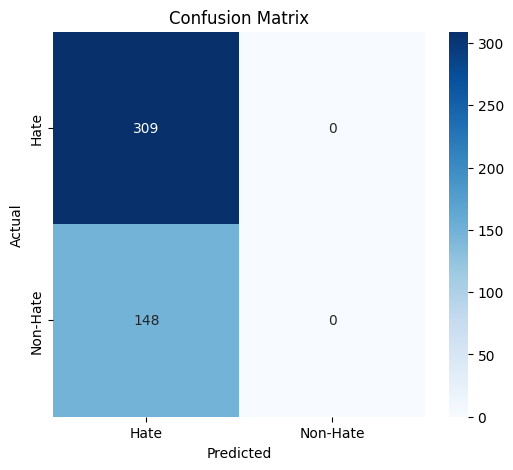

In [18]:
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues", xticklabels=["Hate", "Non-Hate"], yticklabels=["Hate", "Non-Hate"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


# `LSTM Classifier`

In [19]:

class LSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim=100, hidden_dim=128, num_layers=2, pretrained_embeddings=None):
        super().__init__()

        embed_dim = pretrained_embeddings.shape[1]

        self.embedding = nn.Embedding.from_pretrained(pretrained_embeddings, freeze=False, padding_idx=0)

        self.lstm = nn.LSTM(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=False,
            dropout=0.3 if num_layers > 1 else 0.0  # Only applies if num_layers > 1
        )

        self.dropout = nn.Dropout(0.5)
        self.layernorm = nn.LayerNorm(hidden_dim)
        self.fc1 = nn.Linear(hidden_dim, 64)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(64, 1)

    def forward(self, x):
        x = self.embedding(x)                             # [batch, seq, embed]
        _, (h_n, _) = self.lstm(x)                         # h_n: [num_layers, batch, hidden]
        x = h_n[-1]                                        # Take output of the top LSTM layer
        x = self.layernorm(x)
        x = self.dropout(x)
        x = self.relu(self.fc1(x))
        return self.fc2(x).squeeze(1)       

In [ ]:
"""
MODEL TRAINING CODE

lstm_model = LSTMClassifier(vocab_size=vocab_size, pretrained_embeddings=pretrained_embeddings)
train(lstm_model, train_loader, val_loader, num_epochs=50, model_name="lstm_model_50epoch")



"""

Epoch 1/50, Loss: 0.6805
Epoch 2/50, Loss: 0.6774
Epoch 3/50, Loss: 0.6739
Epoch 4/50, Loss: 0.6707
Epoch 5/50, Loss: 0.6691
Epoch 6/50, Loss: 0.6676
Epoch 7/50, Loss: 0.6693
Epoch 8/50, Loss: 0.6700
Epoch 9/50, Loss: 0.6666
Epoch 10/50, Loss: 0.6644
Epoch 11/50, Loss: 0.6675
Epoch 12/50, Loss: 0.6675
Epoch 13/50, Loss: 0.6724
Epoch 14/50, Loss: 0.6682
Epoch 15/50, Loss: 0.6684
Epoch 16/50, Loss: 0.6674
Epoch 17/50, Loss: 0.6672
Epoch 18/50, Loss: 0.6677
Epoch 19/50, Loss: 0.6631
Epoch 20/50, Loss: 0.6696
Epoch 21/50, Loss: 0.6662
Epoch 22/50, Loss: 0.6646
Epoch 23/50, Loss: 0.6662
Epoch 24/50, Loss: 0.6630
Epoch 25/50, Loss: 0.6671
Epoch 26/50, Loss: 0.6654
Epoch 27/50, Loss: 0.6660
Epoch 28/50, Loss: 0.6695
Epoch 29/50, Loss: 0.6672
Epoch 30/50, Loss: 0.6680
Epoch 31/50, Loss: 0.6657
Epoch 32/50, Loss: 0.6660
Epoch 33/50, Loss: 0.6646
Epoch 34/50, Loss: 0.6680
Epoch 35/50, Loss: 0.6666
Epoch 36/50, Loss: 0.6663
Epoch 37/50, Loss: 0.6636
Epoch 38/50, Loss: 0.6657
Epoch 39/50, Loss: 0.

In [20]:
# Load the saved model
lstm_model = LSTMClassifier(vocab_size=vocab_size, pretrained_embeddings=pretrained_embeddings)
lstm_model.load_state_dict(torch.load("lstm_model_50epoch.pt"))
lstm_model.eval()


LSTMClassifier(
  (embedding): Embedding(12933, 100, padding_idx=0)
  (lstm): LSTM(100, 128, num_layers=2, batch_first=True, dropout=0.3)
  (dropout): Dropout(p=0.5, inplace=False)
  (layernorm): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
  (fc1): Linear(in_features=128, out_features=64, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=64, out_features=1, bias=True)
)

In [21]:
all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in val_loader:
        outputs = lstm_model(inputs)
        probs = torch.sigmoid(outputs)
        preds = (probs > 0.4).long()
        
        all_preds.extend(preds.tolist())
        all_labels.extend(labels.tolist())


In [22]:
print("Classification Report:\n")
print(classification_report(all_labels, all_preds, digits=4, target_names=["Hate", "Non-Hate"]))


Classification Report:

              precision    recall  f1-score   support

        Hate     0.6761    1.0000    0.8068       309
    Non-Hate     0.0000    0.0000    0.0000       148

    accuracy                         0.6761       457
   macro avg     0.3381    0.5000    0.4034       457
weighted avg     0.4572    0.6761    0.5455       457



/home/dse316/.conda/envs/tanishq_1/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/dse316/.conda/envs/tanishq_1/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/dse316/.conda/envs/tanishq_1/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitaliz

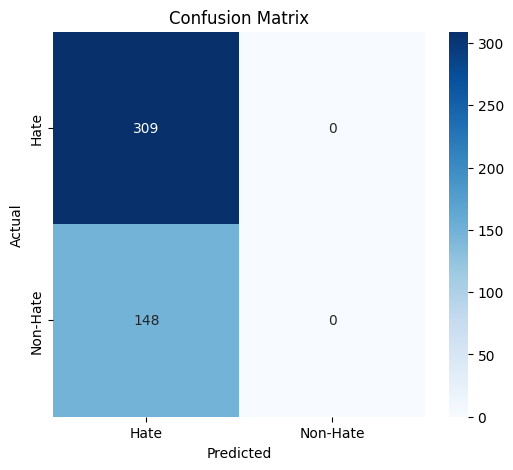

In [23]:
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues", xticklabels=["Hate", "Non-Hate"], yticklabels=["Hate", "Non-Hate"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


# `Transformer`

In [24]:
import math
import torch.nn as nn
import torch

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2) * -(math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)  # [1, max_len, d_model]
        self.register_buffer('pe', pe)

    def forward(self, x):
        x = x + self.pe[:, :x.size(1)]
        return x


In [25]:
class TransformerClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim=128, num_heads=4, num_layers=2, ff_dim=256, dropout=0.1, pretrained_embeddings=None, max_len=5000):
        super().__init__()
        self.embedding = nn.Embedding.from_pretrained(pretrained_embeddings, freeze=False)
        self.pos_encoder = PositionalEncoding(embed_dim, max_len)
        encoder_layer = nn.TransformerEncoderLayer(embed_dim, num_heads, ff_dim, dropout, batch_first=True)
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers)
        self.fc = nn.Linear(embed_dim, 1)

    def forward(self, x):
        x = self.embedding(x)
        x = self.pos_encoder(x)
        x = self.transformer_encoder(x)  # [batch, seq, embed_dim]
        x = x.mean(dim=1)  # Mean pooling over sequence
        return self.fc(x).squeeze(1)


In [ ]:
"""
MODEL TRAINING CODE

transformer_model = TransformerClassifier(vocab_size, embed_dim=100, pretrained_embeddings=pretrained_embeddings)
train(transformer_model, train_loader, val_loader, num_epochs=50, model_name="transformer_model")


"""

Epoch 1/50, Loss: 0.6542
Epoch 2/50, Loss: 0.6526
Epoch 3/50, Loss: 0.6525
Epoch 4/50, Loss: 0.6518
Epoch 5/50, Loss: 0.6520
Epoch 6/50, Loss: 0.6525
Epoch 7/50, Loss: 0.6524
Epoch 8/50, Loss: 0.6520
Epoch 9/50, Loss: 0.6520
Epoch 10/50, Loss: 0.6515
Epoch 11/50, Loss: 0.6515
Epoch 12/50, Loss: 0.6514
Epoch 13/50, Loss: 0.6519
Epoch 14/50, Loss: 0.6513
Epoch 15/50, Loss: 0.6515
Epoch 16/50, Loss: 0.6515
Epoch 17/50, Loss: 0.6520
Epoch 18/50, Loss: 0.6512
Epoch 19/50, Loss: 0.6517
Epoch 20/50, Loss: 0.6514
Epoch 21/50, Loss: 0.6512
Epoch 22/50, Loss: 0.6514
Epoch 23/50, Loss: 0.6514
Epoch 24/50, Loss: 0.6511
Epoch 25/50, Loss: 0.6512
Epoch 26/50, Loss: 0.6501
Epoch 27/50, Loss: 0.6508
Epoch 28/50, Loss: 0.6497
Epoch 29/50, Loss: 0.6511
Epoch 30/50, Loss: 0.6503
Epoch 31/50, Loss: 0.6493
Epoch 32/50, Loss: 0.6505
Epoch 33/50, Loss: 0.6506
Epoch 34/50, Loss: 0.6497
Epoch 35/50, Loss: 0.6502
Epoch 36/50, Loss: 0.6507
Epoch 37/50, Loss: 0.6500
Epoch 38/50, Loss: 0.6498
Epoch 39/50, Loss: 0.

RuntimeError: Expected all tensors to be on the same device, but found at least two devices, cuda:0 and cpu! (when checking argument for argument index in method wrapper_CUDA__index_select)

Classification Report:

              precision    recall  f1-score   support

        Hate     0.7024    0.9320    0.8011       309
    Non-Hate     0.5532    0.1757    0.2667       148

    accuracy                         0.6871       457
   macro avg     0.6278    0.5539    0.5339       457
weighted avg     0.6541    0.6871    0.6280       457



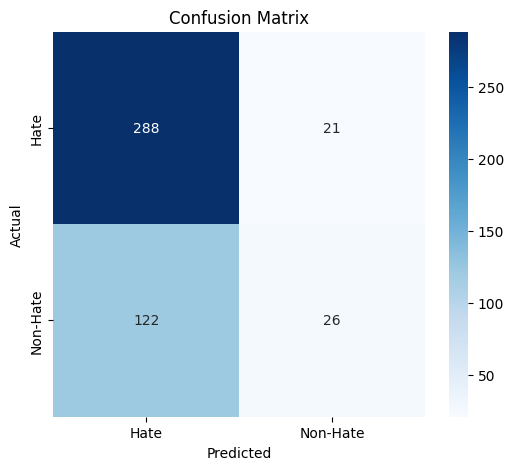

In [26]:
# Load the saved model
transformer_model = TransformerClassifier(vocab_size=vocab_size, embed_dim=100, pretrained_embeddings=pretrained_embeddings)
transformer_model.load_state_dict(torch.load("transformer_model.pt"))
transformer_model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in val_loader:
        outputs = transformer_model(inputs)
        probs = torch.sigmoid(outputs)
        preds = (probs > 0.4).long()
        
        all_preds.extend(preds.tolist())
        all_labels.extend(labels.tolist())

print("Classification Report:\n")
print(classification_report(all_labels, all_preds, digits=4, target_names=["Hate", "Non-Hate"]))

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues", xticklabels=["Hate", "Non-Hate"], yticklabels=["Hate", "Non-Hate"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


# `Bert transformer`

In [1]:
from transformers import BertTokenizer, BertModel
from torch.utils.data import Dataset

tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

class HateDataset(Dataset):
    def __init__(self, sentences, labels, tokenizer, max_length=128):
        self.encodings = tokenizer(sentences, padding=True, truncation=True, max_length=max_length, return_tensors="pt")
        self.labels = torch.tensor(labels)

    def __getitem__(self, idx):
        item = {key: val[idx] for key, val in self.encodings.items()}
        item["labels"] = self.labels[idx]
        return item

    def __len__(self):
        return len(self.labels)


/home/dse316/.conda/envs/tanishq_1/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
class BERTDataset(Dataset):
    def __init__(self, data, tokenizer, max_len=128):
        self.sentences = data["Sentence"].tolist()
        self.labels = data["Tag"].tolist()
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self): return len(self.sentences)

    def __getitem__(self, idx):
        encoding = self.tokenizer.encode_plus(
            self.sentences[idx],
            add_special_tokens=True,
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt'
        )
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'label': torch.tensor(self.labels[idx], dtype=torch.long)
        }


In [5]:
class BERTClassifier(nn.Module):
    def __init__(self, output_dim=100):
        super().__init__()
        self.bert = BertModel.from_pretrained("bert-base-uncased")

        # 🔒 Freeze all BERT layers
        for param in self.bert.parameters():
            param.requires_grad = False

        # 🔄 Only train this classifier head
        self.dropout = nn.Dropout(0.3)
        self.fc = nn.Linear(self.bert.config.hidden_size, output_dim)

    def forward(self, input_ids, attention_mask):
        with torch.no_grad():  # Still allows gradient flow through classifier
            outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        pooled = self.dropout(outputs.pooler_output)
        return self.fc(pooled)


In [8]:

output_dim = len(set(train_df["Tag"]))
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

bert_model = BERTClassifier(output_dim=output_dim)
val_bert_loader = DataLoader(BERTDataset(val_df, tokenizer), batch_size=512)

# BERT model Training
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
train_bert_loader = DataLoader(BERTDataset(train_df, tokenizer), batch_size=512, shuffle=True)
bert_model = BERTClassifier(output_dim=output_dim).to(device)
optimizer = optim.Adam(bert_model.parameters(), lr=2e-3)
criterion = nn.CrossEntropyLoss()

In [ ]:
for epoch in range(50):
        bert_model.train()
        total_loss = 0
        for batch in train_bert_loader:
            input_ids = batch['input_ids'].to(device)
            mask = batch['attention_mask'].to(device)
            labels = batch['label'].to(device)

            optimizer.zero_grad()
            outputs = bert_model(input_ids, mask)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        print(f"[BERT Epoch {epoch+1}] Loss: {total_loss:.4f}")

torch.save(bert_model.fc.state_dict(), f"BERT_50epoch.pth")

[BERT Epoch 1] Loss: 5.5366
[BERT Epoch 2] Loss: 5.4387
[BERT Epoch 3] Loss: 5.2629
[BERT Epoch 4] Loss: 5.2929
[BERT Epoch 5] Loss: 5.3379
[BERT Epoch 6] Loss: 5.2808
[BERT Epoch 7] Loss: 5.3395
[BERT Epoch 8] Loss: 5.2541
[BERT Epoch 9] Loss: 5.2788
[BERT Epoch 10] Loss: 5.1728
[BERT Epoch 11] Loss: 5.2176
[BERT Epoch 12] Loss: 5.1874
[BERT Epoch 13] Loss: 5.1925
[BERT Epoch 14] Loss: 5.3395
[BERT Epoch 15] Loss: 5.2429
[BERT Epoch 16] Loss: 5.2470
[BERT Epoch 17] Loss: 5.2246
[BERT Epoch 18] Loss: 5.1535
[BERT Epoch 19] Loss: 5.1380
[BERT Epoch 20] Loss: 5.1318
[BERT Epoch 21] Loss: 5.1487
[BERT Epoch 22] Loss: 5.2703
[BERT Epoch 23] Loss: 5.1646
[BERT Epoch 24] Loss: 5.2024


In [ ]:
bert_model.fc.load_state_dict(torch.load(f"BERT_50epoch.pth", map_location=device))


<All keys matched successfully>

/home/dse316/.conda/envs/tanishq_1/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/dse316/.conda/envs/tanishq_1/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/dse316/.conda/envs/tanishq_1/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitaliz

              precision    recall  f1-score   support

        hate     0.9029    1.0000    0.9489       474
    non-hate     0.0000    0.0000    0.0000        51

    accuracy                         0.9029       525
   macro avg     0.4514    0.5000    0.4745       525
weighted avg     0.8152    0.9029    0.8568       525



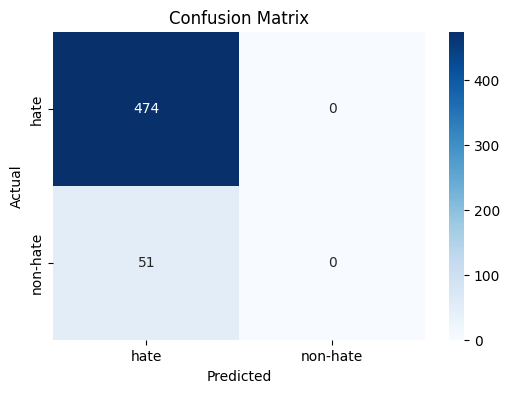

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Make sure model is on the right device and in eval mode
bert_model.eval()
bert_model.to(device)

all_preds = []
all_labels = []

with torch.no_grad():
    for batch in val_bert_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['label'].to(device)

        outputs = bert_model(input_ids, attention_mask)
        preds = torch.argmax(outputs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# 🎯 Classification report
print(classification_report(all_labels, all_preds, target_names=["hate", "non-hate"], digits=4))

# 📊 Confusion matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=["hate", "non-hate"], yticklabels=["hate", "non-hate"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()
